# FERES Stroke Territory Analysis

This notebook implements the requested FERES analysis flow with the MVP `mip.Client` / `mip.AnalysisSet` / `mip.Pipeline` API.

It uses data model `Stroke:3.7` and dataset `SSR`. The ACS/PCS comparison cohort is created as a derived categorical column from `clinical_sdr` filter rules.

## 1. Load client, catalog, and SSR data

`Client.from_env()` expects `PLATFORM_BACKEND_URL` or `MIP_BASE_URL`. In local testing, this notebook was launched with `PLATFORM_BACKEND_URL=http://127.0.0.1:8080/services`.

In [32]:
import mip
from mip.filters import F
from mip.preprocessing import (
    CategoricalColumnCreator,
    MissingValuesHandler,
    OutlierWinsorizer,
)

client = mip.Client.from_env()
catalog = client.catalog()

dm = catalog.data_model("Stroke", version="3.7")
ssr = dm.datasets["SSR"]

dm.summary(), ssr.summary()

({'code': 'Stroke',
  'version': '3.7',
  'label': 'Stroke 3.7',
  'longitudinal': False,
  'n_variables': 197,
  'n_datasets': 3},
 {'code': 'SSR', 'label': 'SSR', 'n_variables': 197})

## 2. Select variables

The analysis uses `clinical_sdr` as the vascular-anatomy source for ACS/PCS derivation:

- `1`: TACS, total anterior circulation syndrome
- `2`: PACS, partial anterior circulation syndrome
- `4`: POCS, posterior circulation syndrome

In [33]:
age = dm.variables["age"]
nihss_24h = dm.variables["nihss_24h"]
nihss_adm = dm.variables["nihss_adm_score"]
sex = dm.variables["biol_sex"]
ivt = dm.variables["acute_treat_ivt"]
evt = dm.variables["acute_treat_evt"]
clinical_sdr = dm.variables["clinical_sdr"]
event_type = dm.variables["event_type"]
good_outcome = dm.variables["fu_3m_mrs_good"]

selected_variables = [
    age,
    nihss_24h,
    nihss_adm,
    sex,
    ivt,
    evt,
    clinical_sdr,
    event_type,
    good_outcome,
]

{variable.code: variable.summary() for variable in selected_variables}

{'age': {'code': 'age',
  'label': 'Age',
  'type': 'integer',
  'categorical': False,
  'numerical': True},
 'nihss_24h': {'code': 'nihss_24h',
  'label': '24h score',
  'type': 'integer',
  'categorical': False,
  'numerical': True},
 'nihss_adm_score': {'code': 'nihss_adm_score',
  'label': 'Admission score',
  'type': 'integer',
  'categorical': False,
  'numerical': True},
 'biol_sex': {'code': 'biol_sex',
  'label': 'Sex',
  'type': 'nominal',
  'categorical': True,
  'numerical': False},
 'acute_treat_ivt': {'code': 'acute_treat_ivt',
  'label': 'IVT',
  'type': 'nominal',
  'categorical': True,
  'numerical': False},
 'acute_treat_evt': {'code': 'acute_treat_evt',
  'label': 'EVT',
  'type': 'nominal',
  'categorical': True,
  'numerical': False},
 'clinical_sdr': {'code': 'clinical_sdr',
  'label': 'Clinical syndrome',
  'type': 'nominal',
  'categorical': True,
  'numerical': False},
 'event_type': {'code': 'event_type',
  'label': 'Event type',
  'type': 'nominal',
  'catego

In [34]:
analysis_set = mip.AnalysisSet(
    data_model=dm,
    datasets=[ssr],
    variables=selected_variables,
)

analysis_set.summary()

{'data_model': 'Stroke:3.7',
 'datasets': ['SSR'],
 'variables': ['age',
  'nihss_24h',
  'nihss_adm_score',
  'biol_sex',
  'acute_treat_ivt',
  'acute_treat_evt',
  'clinical_sdr',
  'event_type',
  'fu_3m_mrs_good']}

## 3. Create ACS / PCS cohort

The cohort is created by backend preprocessing with `categorical_column_creator`. It is intentionally derived from filter rules instead of being read from the catalog.

In [35]:
stroke_territory_creator = CategoricalColumnCreator(
    code="stroke_territory_cohort",
    label="Stroke territory cohort",
    rules={
        "ACS": F(clinical_sdr).isin(["1", "2"]),
        "PCS": F(clinical_sdr) == "4",
    },
    default_enumeration="other_or_unknown",
)

stroke_territory_cohort = stroke_territory_creator.variable
COHORT_ORDER = ["ACS", "PCS"]

stroke_territory_cohort.metadata()

{'code': 'stroke_territory_cohort',
 'label': 'Stroke territory cohort',
 'sql_type': 'text',
 'is_categorical': True,
 'enumerations': {'ACS': 'ACS',
  'PCS': 'PCS',
  'other_or_unknown': 'other_or_unknown'},
 'derived': True,
 'created_by': 'categorical_column_creator'}

## 4. Build the common pipeline

The common filter keeps ischemic stroke records and the strict ACS/PCS source categories. Derived variables are created after filtering and preprocessing, then can be used by downstream algorithms.

In [36]:
common_filters = (
    (F(event_type) == "1")
    & F(clinical_sdr).isin(["1", "2", "4"])
    & F(age).is_not_null()
    & F(nihss_24h).is_not_null()
    & F(sex).isin(["1", "2"])
    & F(good_outcome).isin(["0", "1"])
)

common_missing = MissingValuesHandler(
    strategies={
        age: "median",
        nihss_24h: "median",
        nihss_adm: "median",
        sex: "most_frequent",
        ivt: "most_frequent",
        evt: "most_frequent",
        good_outcome: "most_frequent",
    }
)

common_outliers = OutlierWinsorizer(
    strategies={
        age: "iqr",
        nihss_24h: "iqr",
        nihss_adm: "iqr",
    },
    tails={
        age: "both",
        nihss_24h: "both",
        nihss_adm: "both",
    },
    folds={
        age: 1.5,
        nihss_24h: 1.5,
        nihss_adm: 1.5,
    },
)

pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=common_filters,
    handle_missing=common_missing,
    outlier_handling=common_outliers,
    new_columns=[stroke_territory_creator],
)

pipeline.explain()

{'analysis_set': {'data_model': 'Stroke:3.7',
  'datasets': ['SSR'],
  'variables': ['age',
   'nihss_24h',
   'nihss_adm_score',
   'biol_sex',
   'acute_treat_ivt',
   'acute_treat_evt',
   'clinical_sdr',
   'event_type',
   'fu_3m_mrs_good']},
 'filters': {'condition': 'AND',
  'rules': [{'condition': 'AND',
    'rules': [{'condition': 'AND',
      'rules': [{'condition': 'AND',
        'rules': [{'condition': 'AND',
          'rules': [{'id': 'event_type',
            'field': 'event_type',
            'operator': 'equal',
            'value': '1',
            'type': 'string'},
           {'id': 'clinical_sdr',
            'field': 'clinical_sdr',
            'operator': 'in',
            'value': ['1', '2', '4'],
            'type': 'string'}]},
         {'id': 'age',
          'field': 'age',
          'operator': 'is_not_null',
          'value': None,
          'type': 'string'}]},
       {'id': 'nihss_24h',
        'field': 'nihss_24h',
        'operator': 'is_not_null',
   

## 5. Aggregate visual summaries

These plots use aggregate results returned by the MIP analysis API. Distribution-style plots such as histograms or boxplots are intentionally avoided unless aggregate bins or raw observations are available.

ACS/PCS group-specific descriptions use separate pipelines filtered on `clinical_sdr`, because pipeline filters execute before derived columns are created.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


def _histogram_bins_counts(hist_result):
    summary = hist_result.summary()
    histogram = summary.get("histogram") if isinstance(summary, dict) else None
    if isinstance(histogram, list) and histogram:
        first = histogram[0]
        if isinstance(first, dict):
            return first.get("bins") or [], first.get("counts") or []
    if isinstance(summary, dict):
        return summary.get("bins") or summary.get("x") or [], summary.get("counts") or summary.get("y") or []
    return [], []


def _cohort_counts_from_histogram(hist_result):
    bins, counts = _histogram_bins_counts(hist_result)
    rows = []
    for level, count in zip(bins, counts):
        rows.append(
            {
                "level": level,
                "count": count,
                "missing": pd.isna(count) or count is None,
            }
        )
    return pd.DataFrame(rows)


def _featurewise_rows(result, cohort_label, variables=None):
    summary = result.summary()
    featurewise = summary.get("featurewise", []) if isinstance(summary, dict) else []
    rows = []
    for item in featurewise:
        if item.get("dataset") != "SSR":
            continue
        variable = item.get("variable")
        if variables is not None and variable not in variables:
            continue
        data = item.get("data") or {}
        row = {"cohort": cohort_label, "variable": variable}
        row.update(data)
        rows.append(row)
    return rows


def _numeric_df_from_describe(acs_result, pcs_result, variables):
    rows = _featurewise_rows(acs_result, "ACS", variables) + _featurewise_rows(pcs_result, "PCS", variables)
    numeric_df = pd.DataFrame(rows)
    numeric_df = numeric_df[numeric_df["mean"].notna()].copy()
    numeric_df["missing_rate"] = numeric_df["num_na"] / numeric_df["num_total"]
    numeric_df["sem"] = numeric_df["std"] / np.sqrt(numeric_df["num_dtps"])
    numeric_df["ci95"] = 1.96 * numeric_df["sem"]
    return numeric_df


def _enumeration_label_map(variable):
    metadata = variable.metadata()
    enums = metadata.get("enumerations") or metadata.get("enums") or {}
    if isinstance(enums, dict):
        return {str(code): str(label) for code, label in enums.items()}
    if isinstance(enums, (list, tuple)):
        result = {}
        for item in enums:
            if isinstance(item, dict):
                code = item.get("code") or item.get("value")
                label = item.get("label") or item.get("name") or code
                if code is not None:
                    result[str(code)] = str(label)
            else:
                result[str(item)] = str(item)
        return result
    return {}


def _level_label(enum_map, level):
    return enum_map.get(str(level), str(level))


def _categorical_df_from_describe(acs_result, pcs_result, variable):
    variable_code = variable.code
    enum_map = _enumeration_label_map(variable)
    rows = []
    for cohort_label, result in [("ACS", acs_result), ("PCS", pcs_result)]:
        for item in _featurewise_rows(result, cohort_label, [variable_code]):
            counts = item.get("counts") or {}
            total = float(item.get("num_dtps") or sum(counts.values()) or 0)
            for level, count in counts.items():
                rows.append(
                    {
                        "cohort": cohort_label,
                        "variable": variable_code,
                        "variable_label": variable.label,
                        "level": level,
                        "level_label": _level_label(enum_map, level),
                        "count": count,
                        "percent": (100.0 * float(count) / total) if total else np.nan,
                    }
                )
    return pd.DataFrame(rows)


def _ttest_df_from_results(results_by_variable):
    rows = []
    for variable, result in results_by_variable.items():
        summary = result.summary()
        if not isinstance(summary, dict):
            continue
        rows.append(
            {
                "variable": variable,
                "t_stat": summary.get("t_stat"),
                "df": summary.get("df"),
                "p_value": summary.get("p"),
                "mean_diff": summary.get("mean_diff"),
                "ci_low": summary.get("ci_lower"),
                "ci_high": summary.get("ci_upper"),
                "cohens_d": summary.get("cohens_d"),
            }
        )
    return pd.DataFrame(rows)


def _logistic_term_label(term, variables_by_code):
    if term == "Intercept":
        return "Intercept"
    if "[" in term and term.endswith("]"):
        base, level = term.split("[", 1)
        level = level[:-1]
        variable = variables_by_code.get(base)
        if variable is not None:
            level_text = _level_label(_enumeration_label_map(variable), level)
            if base == stroke_territory_cohort.code and level == "PCS":
                return "PCS vs ACS"
            return f"{variable.label} = {level_text}"
    variable = variables_by_code.get(term)
    if variable is not None:
        return variable.label
    return term


def _format_p_value(p):
    if pd.isna(p):
        return "—"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def _logistic_result_to_dataframe(result):
    payload = result.summary()
    summary = payload["summary"]

    df = pd.DataFrame(
        {
            "term": payload["indep_vars"],
            "coef": summary["coefficients"],
            "stderr": summary["stderr"],
            "lower_ci": summary["lower_ci"],
            "upper_ci": summary["upper_ci"],
            "z_score": summary["z_scores"],
            "p_value": summary["pvalues"],
        }
    )

    df["odds_ratio"] = np.exp(df["coef"])
    df["or_lower_ci"] = np.exp(df["lower_ci"])
    df["or_upper_ci"] = np.exp(df["upper_ci"])

    return df

### Cohort validation

,level,count,missing
0,ACS,19952,False
1,PCS,7356,False
2,other_or_unknown,—,True


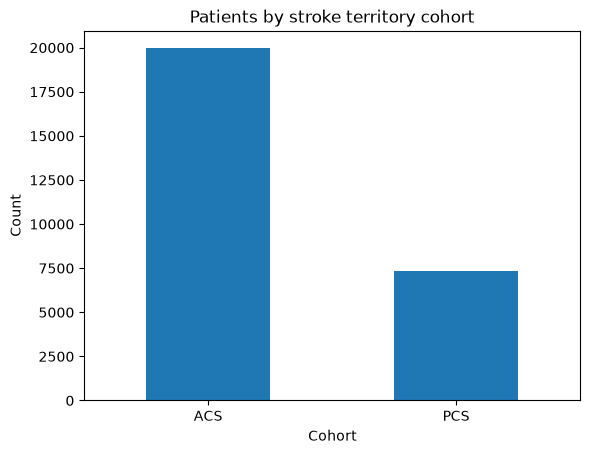

In [38]:
display(Markdown("### Cohort validation"))

cohort_hist = pipeline.histogram(variable=stroke_territory_cohort, bins=3)
cohort_df = _cohort_counts_from_histogram(cohort_hist)

display(
    cohort_df.style.format({"count": "{:.0f}"}, na_rep="—")
)

cohort_counts = (
    cohort_df[~cohort_df["missing"]]
    .set_index("level")
    .reindex(COHORT_ORDER)
)

ax = cohort_counts["count"].plot(kind="bar", legend=False)
ax.set_title("Patients by stroke territory cohort")
ax.set_xlabel("Cohort")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 6. Numeric summaries by cohort

95% CIs are approximate and computed from aggregate mean, standard deviation, and count.

### Numeric summaries by cohort

,cohort,variable,num_dtps,num_na,missing_rate,mean,std,q2
0,ACS,age,19952.000000,0.000000,0.0%,72.76,12.91,75.00
1,ACS,nihss_24h,19952.000000,0.000000,0.0%,4.18,4.47,2.00
2,PCS,age,7356.000000,0.000000,0.0%,69.16,14.11,72.00
3,PCS,nihss_24h,7356.000000,0.000000,0.0%,1.79,2.24,1.00


### Mean comparisons with approximate 95% CI

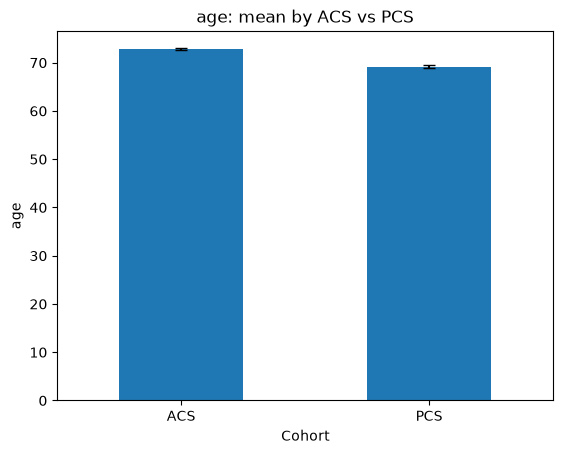

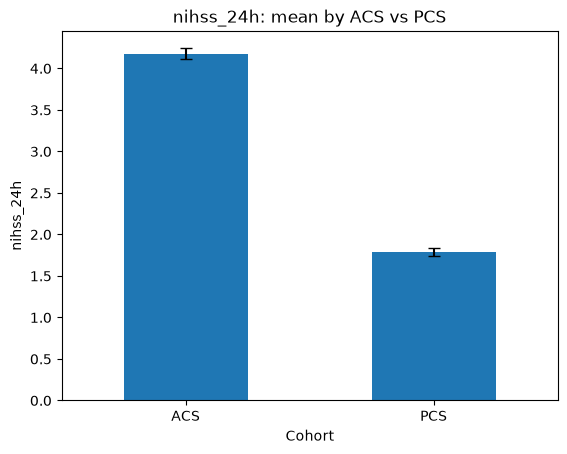

In [39]:
acs_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=common_filters & F(clinical_sdr).isin(["1", "2"]),
    handle_missing=common_missing,
    outlier_handling=common_outliers,
    new_columns=[stroke_territory_creator],
)

pcs_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=common_filters & (F(clinical_sdr) == "4"),
    handle_missing=common_missing,
    outlier_handling=common_outliers,
    new_columns=[stroke_territory_creator],
)

acs_numerical_summary = acs_pipeline.describe()
pcs_numerical_summary = pcs_pipeline.describe()

display(Markdown("### Numeric summaries by cohort"))

numeric_df = _numeric_df_from_describe(
    acs_numerical_summary,
    pcs_numerical_summary,
    variables=["age", "nihss_24h"],
)

display(
    numeric_df[
        ["cohort", "variable", "num_dtps", "num_na", "missing_rate", "mean", "std", "q2"]
    ].style.format(
        {
            "missing_rate": "{:.1%}",
            "mean": "{:.2f}",
            "std": "{:.2f}",
            "q2": "{:.2f}",
        },
        na_rep="—",
    )
)

display(Markdown("### Mean comparisons with approximate 95% CI"))

for variable, sub in numeric_df.groupby("variable"):
    sub = sub.set_index("cohort").reindex(COHORT_ORDER)

    ax = sub["mean"].plot(
        kind="bar",
        yerr=sub["ci95"],
        capsize=4,
        legend=False,
    )
    ax.set_title(f"{variable}: mean by ACS vs PCS")
    ax.set_xlabel("Cohort")
    ax.set_ylabel(variable)
    plt.xticks(rotation=0)
    plt.show()

## 7. Categorical summaries by cohort

### Categorical summaries by cohort

#### Sex (`biol_sex`)

,cohort,variable_label,level_label,count,percent
0,ACS,Sex,male,11337,56.8%
1,ACS,Sex,female,8615,43.2%
2,PCS,Sex,male,4642,63.1%
3,PCS,Sex,female,2714,36.9%


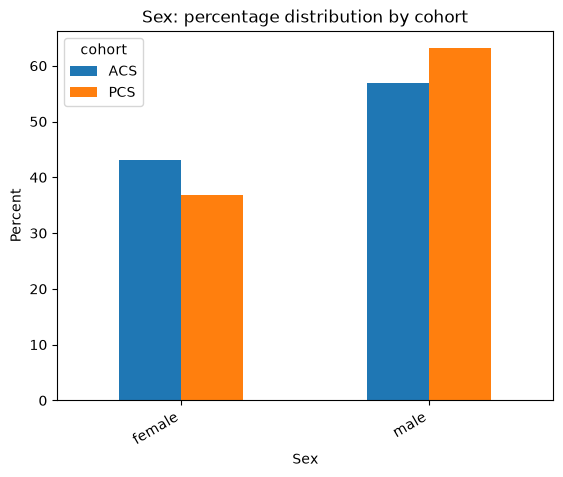

#### IVT (`acute_treat_ivt`)

,cohort,variable_label,level_label,count,percent
0,ACS,IVT,no,13407,67.2%
1,ACS,IVT,yes,6545,32.8%
2,PCS,IVT,no,6018,81.8%
3,PCS,IVT,yes,1338,18.2%


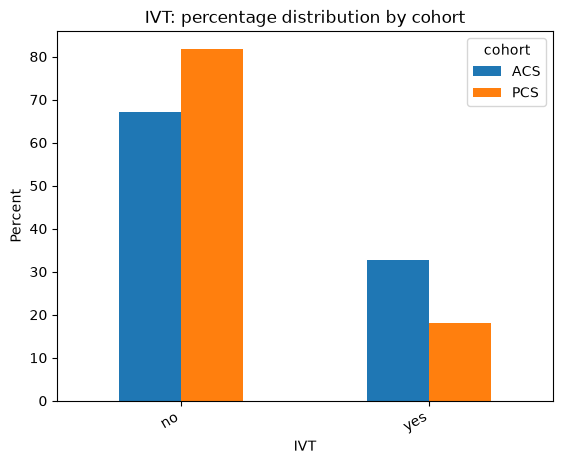

#### EVT (`acute_treat_evt`)

,cohort,variable_label,level_label,count,percent
0,ACS,EVT,no,15397,77.2%
1,ACS,EVT,yes,4555,22.8%
2,PCS,EVT,no,6952,94.5%
3,PCS,EVT,yes,404,5.5%


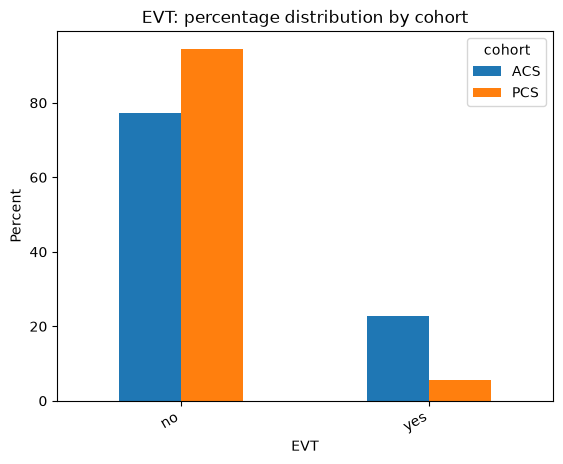

In [40]:
display(Markdown("### Categorical summaries by cohort"))

categorical_variables = [sex, ivt, evt]

for variable in categorical_variables:
    cat_df = _categorical_df_from_describe(
        acs_numerical_summary,
        pcs_numerical_summary,
        variable=variable,
    )

    display(Markdown(f"#### {variable.label} (`{variable.code}`)"))

    display(
        cat_df[
            ["cohort", "variable_label", "level_label", "count", "percent"]
        ].style.format(
            {
                "percent": "{:.1f}%",
                "count": "{:.0f}",
            },
            na_rep="—",
        )
    )

    pivot = (
        cat_df.pivot(index="level_label", columns="cohort", values="percent")
        .reindex(columns=COHORT_ORDER)
    )

    ax = pivot.plot(kind="bar")
    ax.set_title(f"{variable.label}: percentage distribution by cohort")
    ax.set_xlabel(variable.label)
    ax.set_ylabel("Percent")
    plt.xticks(rotation=30, ha="right")
    plt.show()

## 8. ACS vs PCS statistical comparison

The MVP API exposes independent t-test and chi-square. Mann-Whitney U is not exposed in the current client API, so it is noted here but not executed.

### ACS vs PCS statistical comparison

,variable,t_stat,df,p_value,mean_diff,ci_low,ci_high,cohens_d
0,age,19.17,27306.0,0.0000,3.47,3.12,3.83,0.26
1,nihss_24h,38.90,27306.0,0.0000,2.08,1.98,2.19,0.53


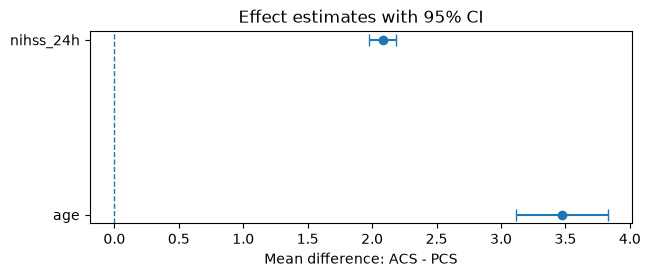

In [41]:
display(Markdown("### ACS vs PCS statistical comparison"))

age_t_test = pipeline.t_test(
    variable=age,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

nihss_24h_t_test = pipeline.t_test(
    variable=nihss_24h,
    group_by=stroke_territory_cohort,
    group_a="ACS",
    group_b="PCS",
)

ttest_df = _ttest_df_from_results(
    {
        "age": age_t_test,
        "nihss_24h": nihss_24h_t_test,
    }
)

display(
    ttest_df.style.format(
        {
            "t_stat": "{:.2f}",
            "df": "{:.1f}",
            "p_value": "{:.4f}",
            "mean_diff": "{:.2f}",
            "ci_low": "{:.2f}",
            "ci_high": "{:.2f}",
            "cohens_d": "{:.2f}",
        },
        na_rep="—",
    )
)

plot_df = ttest_df.dropna(subset=["mean_diff", "ci_low", "ci_high"]).copy()
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(7, max(2.5, 0.6 * len(plot_df))))
ax.errorbar(
    plot_df["mean_diff"],
    y_pos,
    xerr=[
        plot_df["mean_diff"] - plot_df["ci_low"],
        plot_df["ci_high"] - plot_df["mean_diff"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["variable"])
ax.set_xlabel("Mean difference: ACS - PCS")
ax.set_title("Effect estimates with 95% CI")
plt.show()

In [42]:
sex_chi_square = pipeline.chi_square_test(
    x=stroke_territory_cohort,
    y=sex,
)

ivt_chi_square = pipeline.chi_square_test(
    x=stroke_territory_cohort,
    y=ivt,
)

evt_chi_square = pipeline.chi_square_test(
    x=stroke_territory_cohort,
    y=evt,
)

chi_square_rows = []
for label, result in [
    ("sex", sex_chi_square),
    ("ivt", ivt_chi_square),
    ("evt", evt_chi_square),
]:
    summary = result.summary()
    chi_square_rows.append(
        {
            "comparison": label,
            "chi2": summary.get("chi2"),
            "p_value": summary.get("p_value"),
            "dof": summary.get("dof"),
        }
    )

chi_square_df = pd.DataFrame(chi_square_rows)

display(Markdown("### Chi-square tests (stroke territory cohort vs treatment/demographics)"))

display(
    chi_square_df.style.format(
        {
            "chi2": "{:.2f}",
            "p_value": "{:.4g}",
            "dof": "{:.0f}",
        },
        na_rep="—",
    )
)

### Chi-square tests (stroke territory cohort vs treatment/demographics)

,comparison,chi2,p_value,dof
0,sex,87.16,1.002e-20,1
1,ivt,558.32,1.954e-123,1
2,evt,1085.88,3.873e-238,1


## 9. Logistic regression for good 3-month outcome

The target is `fu_3m_mrs_good`, where code `1` means good outcome. The model includes demographics, severity, treatments, and the derived ACS/PCS cohort.

In [43]:
logistic_regression_result = pipeline.logistic_regression(
    x=[
        age,
        nihss_24h,
        nihss_adm,
        sex,
        ivt,
        evt,
        stroke_territory_cohort,
    ],
    y=good_outcome,
    positive_class="1",
)

### Logistic regression: adjusted odds ratios


In [44]:
logreg_payload = logistic_regression_result.summary()
logreg_df = _logistic_result_to_dataframe(logistic_regression_result)

logreg_variables_by_code = {
    sex.code: sex,
    ivt.code: ivt,
    evt.code: evt,
    stroke_territory_cohort.code: stroke_territory_cohort,
    age.code: age,
    nihss_24h.code: nihss_24h,
    nihss_adm.code: nihss_adm,
}

logreg_df["label"] = logreg_df["term"].apply(
    lambda term: _logistic_term_label(term, logreg_variables_by_code)
)
logreg_df["p_value_fmt"] = logreg_df["p_value"].apply(_format_p_value)
logreg_df["or_95_ci"] = logreg_df.apply(
    lambda row: f'{row["odds_ratio"]:.2f} ({row["or_lower_ci"]:.2f}, {row["or_upper_ci"]:.2f})',
    axis=1,
)

display(
    logreg_df[
        ["label", "coef", "stderr", "odds_ratio", "or_lower_ci", "or_upper_ci", "z_score", "p_value"]
    ].style.format(
        {
            "coef": "{:.3f}",
            "stderr": "{:.3f}",
            "odds_ratio": "{:.2f}",
            "or_lower_ci": "{:.2f}",
            "or_upper_ci": "{:.2f}",
            "z_score": "{:.2f}",
            "p_value": "{:.4g}",
        },
        na_rep="—",
    )
)


,label,coef,stderr,odds_ratio,or_lower_ci,or_upper_ci,z_score,p_value
0,Intercept,7.059,0.129,1162.86,903.51,1496.65,54.82,0
1,Sex = female,-0.170,0.035,0.84,0.79,0.90,-4.89,1.024e-06
2,IVT = yes,0.479,0.040,1.62,1.49,1.75,11.84,2.288e-32
3,EVT = yes,0.288,0.050,1.33,1.21,1.47,5.71,1.135e-08
4,PCS vs ACS,-0.010,0.042,0.99,0.91,1.07,-0.24,0.812
5,Age,-0.063,0.002,0.94,0.94,0.94,-39.52,0
6,24h score,-0.322,0.006,0.72,0.72,0.73,-53.74,0
7,Admission score,-0.045,0.005,0.96,0.95,0.96,-9.71,2.716e-22


### Adjusted odds-ratio forest plot


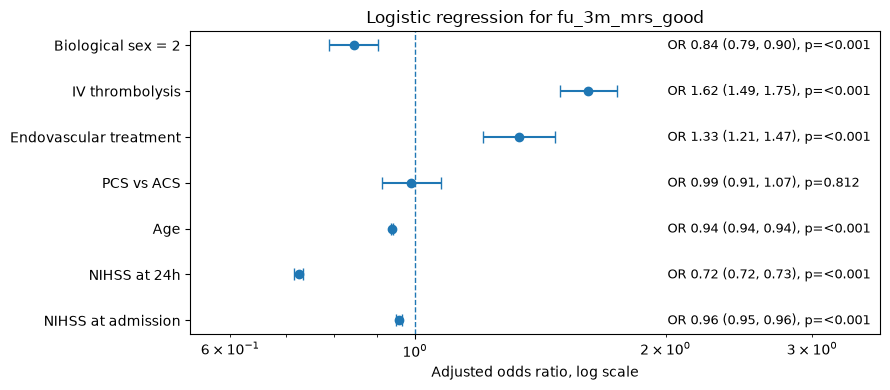

In [14]:
plot_df = logreg_df[logreg_df["term"] != "Intercept"].copy()
plot_df = plot_df.iloc[::-1]

y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9, max(4, 0.55 * len(plot_df))))

xerr = [
    plot_df["odds_ratio"] - plot_df["or_lower_ci"],
    plot_df["or_upper_ci"] - plot_df["odds_ratio"],
]

ax.errorbar(
    plot_df["odds_ratio"],
    y_pos,
    xerr=xerr,
    fmt="o",
    capsize=4,
)

ax.axvline(1, linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Adjusted odds ratio, log scale")
ax.set_title(f'Logistic regression for {logreg_payload["dependent_var"]}')

x_text = plot_df["or_upper_ci"].max() * 1.15

for y, (_, row) in zip(y_pos, plot_df.iterrows()):
    ax.text(
        x_text,
        y,
        f'OR {row["odds_ratio"]:.2f} '
        f'({row["or_lower_ci"]:.2f}, {row["or_upper_ci"]:.2f}), '
        f'p={row["p_value_fmt"]}',
        va="center",
        fontsize=9,
    )

ax.set_xlim(
    max(plot_df["or_lower_ci"].min() * 0.75, 0.01),
    x_text * 1.8,
)

plt.tight_layout()
plt.show()


### Logistic regression model fit


In [15]:
model_summary = logreg_payload["summary"]

fit_df = pd.DataFrame(
    {
        "metric": [
            "N observations",
            "df model",
            "df residual",
            "Cox-Snell pseudo R²",
            "McFadden pseudo R²",
            "Log-likelihood null",
            "Log-likelihood model",
            "AIC",
            "BIC",
        ],
        "value": [
            model_summary.get("n_obs"),
            model_summary.get("df_model"),
            model_summary.get("df_resid"),
            model_summary.get("r_squared_cs"),
            model_summary.get("r_squared_mcf"),
            model_summary.get("ll0"),
            model_summary.get("ll"),
            model_summary.get("aic"),
            model_summary.get("bic"),
        ],
    }
)

display(
    fit_df.style.format(
        {"value": "{:.3f}"},
        na_rep="—",
    )
)


,metric,value
0,N observations,27308.000
1,df model,7.000
2,df residual,27300.000
3,Cox-Snell pseudo R²,0.330
4,McFadden pseudo R²,0.333
5,Log-likelihood null,-16452.217
6,Log-likelihood model,-10977.810
7,AIC,21971.621
8,BIC,22037.340


**Interpretation note:**

The forest plot reports adjusted odds ratios from the logistic regression model. Values above 1 indicate higher odds of `fu_3m_mrs_good`; values below 1 indicate lower odds. Confidence intervals crossing 1 indicate that the corresponding adjusted association is not statistically clear at the 95% confidence level.

The intercept is omitted from the plot because it is not clinically interpretable as a covariate effect.


In [24]:
# Available when backend logistic regression output includes feature names and coefficients.
logistic_regression_result.feature_schema()

{'feature_names': ['biol_sex[2]',
  'acute_treat_ivt[1]',
  'acute_treat_evt[1]',
  'stroke_territory_cohort[PCS]',
  'age',
  'nihss_24h',
  'nihss_adm_score'],
 'input_type': 'pandas.DataFrame',
 'requires_preprocessed_input': True,
 'rule': 'Columns must match sklearn_model.feature_names_in_ exactly and in order.'}

## 10. API availability note

Mann-Whitney U is part of the desired statistical flow, but it is not exposed by the MVP `Pipeline` API yet. If/when the backend exposes it, add a `pipeline.mann_whitney_u(...)` wrapper and run it for `age` and `nihss_24h` grouped by `stroke_territory_cohort`.